In [1]:
import pandas as pd
import numpy as np
RANDOM_SEED = 694973

In [2]:
df=pd.read_csv('baseline_probs.csv')
df['is_made'] = np.where(df['shotResult']=='Made',1,0)
df.head()

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,defTeamId,defTeamTricode,SEASON,distance,angle,shot_type,is_behind_backboard,is_made,logits,probs
0,21000001,2,PT11M43.00S,1,1610612738,BOS,406,O'Neal,S. O'Neal,-4,...,NaN,NaN,2010-11,0.013755,0.117118,LAYUP,0,0,1.337096,0.792012
1,21000001,8,PT10M53.00S,1,1610612748,MIA,2544,James,L. James,144,...,NaN,NaN,2010-11,0.231958,0.263808,JUMPER,0,1,-0.453765,0.388466
2,21000001,9,PT10M35.00S,1,1610612738,BOS,1718,Pierce,P. Pierce,165,...,NaN,NaN,2010-11,0.217050,0.356632,JUMPER,0,0,-0.430534,0.393999
3,21000001,11,PT10M27.00S,1,1610612748,MIA,2548,Wade,D. Wade,21,...,NaN,NaN,2010-11,0.026013,0.403465,LAYUP,0,0,0.462076,0.613506
4,21000001,14,PT10M02.00S,1,1610612748,MIA,2544,James,L. James,-152,...,NaN,NaN,2010-11,0.218443,0.309004,JUMPER,0,0,-0.390337,0.403636


In [3]:
players = pd.read_csv("nba_api_code/nba_player_attributes.csv")
players = players.drop_duplicates(subset=["PLAYER_ID"])
print(players.head())
print(players.shape)

       TeamID   SEASON  LeagueID          PLAYER NICKNAME     PLAYER_SLUG  \
0  1610612737  2010-11         0     Jeff Teague     Jeff     jeff-teague   
1  1610612737  2010-11         0     Joe Johnson      Joe     joe-johnson   
2  1610612737  2010-11         0  Damien Wilkins   Damien  damien-wilkins   
3  1610612737  2010-11         0      Josh Smith     Josh      josh-smith   
4  1610612737  2010-11         0    Kirk Hinrich     Kirk    kirk-hinrich   

   NUM POSITION HEIGHT  WEIGHT    BIRTH_DATE   AGE EXP                 SCHOOL  \
0  0.0        G    6-2   180.0  JUN 10, 1988  23.0   1            Wake Forest   
1  2.0        G    6-7   240.0  JUN 29, 1981  30.0   9               Arkansas   
2  3.0      G-F    6-6   225.0  JAN 11, 1980  31.0   6                Georgia   
3  5.0        F    6-9   240.0  DEC 05, 1985  25.0   6  Oak Hill Academy (VA)   
4  6.0        G    6-4   190.0  JAN 02, 1981  30.0   7                 Kansas   

   PLAYER_ID HOW_ACQUIRED  SUPPLEMENTAL_STATUS  HE

In [4]:
df['personId']=pd.to_numeric(df['personId'])
cdf=df.merge(players[['PLAYER','POSITION','BIRTH_DATE','PLAYER_ID','HEIGHT_INCHES']],how='left',left_on=['personId'],right_on=['PLAYER_ID'])
cdf.head()

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,shot_type,is_behind_backboard,is_made,logits,probs,PLAYER,POSITION,BIRTH_DATE,PLAYER_ID,HEIGHT_INCHES
0,21000001,2,PT11M43.00S,1,1610612738,BOS,406,O'Neal,S. O'Neal,-4,...,LAYUP,0,0,1.337096,0.792012,Shaquille O'Neal,C,"MAR 06, 1972",406.0,85.0
1,21000001,8,PT10M53.00S,1,1610612748,MIA,2544,James,L. James,144,...,JUMPER,0,1,-0.453765,0.388466,LeBron James,F,"DEC 30, 1984",2544.0,80.0
2,21000001,9,PT10M35.00S,1,1610612738,BOS,1718,Pierce,P. Pierce,165,...,JUMPER,0,0,-0.430534,0.393999,Paul Pierce,F,"OCT 13, 1977",1718.0,79.0
3,21000001,11,PT10M27.00S,1,1610612748,MIA,2548,Wade,D. Wade,21,...,LAYUP,0,0,0.462076,0.613506,Dwyane Wade,G,"JAN 17, 1982",2548.0,76.0
4,21000001,14,PT10M02.00S,1,1610612748,MIA,2544,James,L. James,-152,...,JUMPER,0,0,-0.390337,0.403636,LeBron James,F,"DEC 30, 1984",2544.0,80.0


In [5]:
cdf.loc[cdf['PLAYER_ID'].isna(), 'playerNameI'].dropna().unique().tolist()

['F. Oberto',
 'J. Williams',
 'L. Head',
 'R. Carney',
 'P. Mensah-Bonsu',
 'A. Wright',
 'S. Collins',
 'M. Ager',
 'J. Taylor',
 'S. Marks',
 'Q. Ross',
 'J. Collins',
 'I. Udoka',
 'M. Peterson',
 'R. Dupree',
 'O. Greene',
 'M. Harris',
 'K. Weaver',
 'B. Skinner',
 'D. Horner',
 'J. Davis',
 'L. Hughes',
 'C. Johnson',
 'D. Hobson',
 'M. Thompson',
 'R. Reid',
 'A. Emmett',
 'E. Dawson',
 'J. Foote',
 'J. Smith',
 'E. Ubiles',
 'J. Dentmon',
 'K. Benson',
 'R. Wallace',
 'W. Conroy',
 'L. Zeller',
 'D. Johnson-Odom',
 'C. Wright',
 'E. Harris',
 'T. Mitchell',
 'S. Edwards',
 'D. Stephens',
 'A. Dawkins',
 'W. Cherry',
 'D. Gordon',
 'A. Kirk',
 'P. Christopher',
 'D. Wear',
 'S. Bhullar',
 'K. Appling',
 "J. O'Brien",
 'B. Dejean-Jones',
 'A. Stepheson',
 'C. Clarke',
 'N. Laprovittola',
 'P. Jackson',
 'M. Tobey',
 'B. Bentil',
 'G. Clavell',
 'J. Wiley',
 'J. Pullen',
 'J. Wilson',
 'V. Hunter',
 'L. Perrantes',
 'M. Williams Jr.',
 'X. Rathan-Mayes',
 'J. Warney',
 'O. Johnso

In [6]:
cdf.loc[(cdf['BIRTH_DATE'].notna()) & (cdf['HEIGHT_INCHES'].notna()) & (cdf['PLAYER_ID'].notna())].reset_index(drop=True)

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,shot_type,is_behind_backboard,is_made,logits,probs,PLAYER,POSITION,BIRTH_DATE,PLAYER_ID,HEIGHT_INCHES
0,21000001,2,PT11M43.00S,1,1610612738,BOS,406,O'Neal,S. O'Neal,-4,...,LAYUP,0,0,1.337096,0.792012,Shaquille O'Neal,C,"MAR 06, 1972",406.0,85.0
1,21000001,8,PT10M53.00S,1,1610612748,MIA,2544,James,L. James,144,...,JUMPER,0,1,-0.453765,0.388466,LeBron James,F,"DEC 30, 1984",2544.0,80.0
2,21000001,9,PT10M35.00S,1,1610612738,BOS,1718,Pierce,P. Pierce,165,...,JUMPER,0,0,-0.430534,0.393999,Paul Pierce,F,"OCT 13, 1977",1718.0,79.0
3,21000001,11,PT10M27.00S,1,1610612748,MIA,2548,Wade,D. Wade,21,...,LAYUP,0,0,0.462076,0.613506,Dwyane Wade,G,"JAN 17, 1982",2548.0,76.0
4,21000001,14,PT10M02.00S,1,1610612748,MIA,2544,James,L. James,-152,...,JUMPER,0,0,-0.390337,0.403636,LeBron James,F,"DEC 30, 1984",2544.0,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3285770,22501230,723,PT01M04.00S,4,1610612760,OKC,1631114,Williams,J. Williams,-102,...,JUMPER,0,0,-0.309037,0.423350,Jalen Williams,G-F,"APR 14, 2001",1631114.0,77.0
3285771,22501230,725,PT00M40.00S,4,1610612759,SAS,1641705,Wembanyama,V. Wembanyama,70,...,LAYUP,0,0,-0.313468,0.422268,Victor Wembanyama,F-C,"JAN 04, 2004",1641705.0,88.0
3285772,22501230,727,PT00M37.50S,4,1610612759,SAS,1642264,Castle,S. Castle,0,...,LAYUP,0,0,0.690075,0.665983,Stephon Castle,G,"NOV 01, 2004",1642264.0,78.0
3285773,22501230,751,PT00M14.90S,4,1610612760,OKC,1628983,Gilgeous-Alexander,S. Gilgeous-Alexander,-11,...,DUNK,0,1,0.045037,0.511257,Shai Gilgeous-Alexander,G,"JUL 12, 1998",1628983.0,78.0


In [7]:
print(cdf.shape)
cdf = cdf.loc[(cdf['BIRTH_DATE'].notna()) & (cdf['HEIGHT_INCHES'].notna()) & (cdf['PLAYER_ID'].notna())].reset_index(drop=True)
print(cdf.shape)

(3290130, 44)
(3285775, 44)


In [8]:
cdf["birthdate"] = pd.to_datetime(cdf["BIRTH_DATE"], format="%b %d, %Y")
cdf["season_end_year"] = cdf["SEASON"].str.split("-").str[0].astype(int) + 1
cdf["season_date"] = pd.to_datetime(cdf["season_end_year"].astype(str) + "-07-31")
cdf["player_age"] = (cdf["season_date"] - cdf["birthdate"]).dt.days/365.25
cdf.loc[cdf['personId']==1628960][['SEASON','player_age']].head()

,SEASON,player_age
1608401,2018-19,23.811088
1608414,2018-19,23.811088
1610589,2018-19,23.811088
1610600,2018-19,23.811088
1610602,2018-19,23.811088


<Axes: >

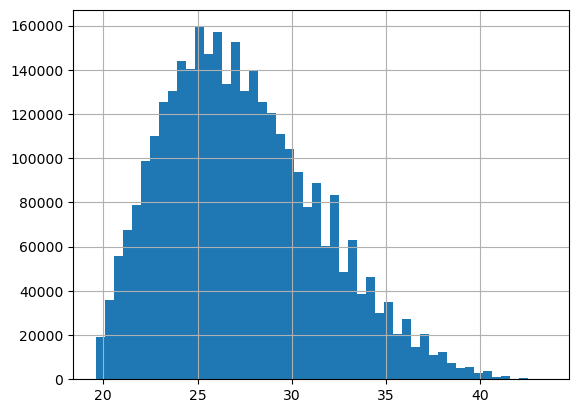

In [9]:
cdf["player_age"].hist(bins=50)

In [10]:
cdf['player_full_id'] = cdf['PLAYER'] + " (" + cdf['PLAYER_ID'].astype(int).astype(str) + ")"
# standardize age
age_mean = np.mean(cdf['player_age'])
age_std = np.std(cdf['player_age'])
cdf['age_z'] = (cdf['player_age'] - age_mean)/age_std
# standardize height
height_mean = np.mean(cdf['HEIGHT_INCHES'])
height_std = np.std(cdf['HEIGHT_INCHES'])
cdf['height_z'] = (cdf['HEIGHT_INCHES'] - height_mean)/height_std
# position remap
cdf['posit'] = cdf['POSITION'].str.split('-').str[0]
cdf = cdf.reset_index(drop=True)
cdf.head()

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,PLAYER_ID,HEIGHT_INCHES,birthdate,season_end_year,season_date,player_age,player_full_id,age_z,height_z,posit
0,21000001,2,PT11M43.00S,1,1610612738,BOS,406,O'Neal,S. O'Neal,-4,...,406.0,85.0,1972-03-06,2011,2011-07-31,39.400411,Shaquille O'Neal (406),2.927118,1.895835,C
1,21000001,8,PT10M53.00S,1,1610612748,MIA,2544,James,L. James,144,...,2544.0,80.0,1984-12-30,2011,2011-07-31,26.581793,LeBron James (2544),-0.187391,0.396514,F
2,21000001,9,PT10M35.00S,1,1610612738,BOS,1718,Pierce,P. Pierce,165,...,1718.0,79.0,1977-10-13,2011,2011-07-31,33.796030,Paul Pierce (1718),1.565435,0.096650,F
3,21000001,11,PT10M27.00S,1,1610612748,MIA,2548,Wade,D. Wade,21,...,2548.0,76.0,1982-01-17,2011,2011-07-31,29.533196,Dwyane Wade (2548),0.529704,-0.802943,G
4,21000001,14,PT10M02.00S,1,1610612748,MIA,2544,James,L. James,-152,...,2544.0,80.0,1984-12-30,2011,2011-07-31,26.581793,LeBron James (2544),-0.187391,0.396514,F


In [11]:
agg = cdf.groupby(['player_full_id','SEASON','shot_type',
                   'PLAYER_ID', 'PLAYER', 'player_age', 'age_z', 'HEIGHT_INCHES', 'height_z','birthdate','posit']
                   ).agg(
        attempts=('is_made', 'size'),
        actual_makes=('is_made', 'sum'),
        expected_makes=('probs', 'sum'),
    ).reset_index()
agg['offset'] = np.log(agg['expected_makes'] / (agg['attempts'] - agg['expected_makes']))
agg.head(10)

,player_full_id,SEASON,shot_type,PLAYER_ID,PLAYER,player_age,age_z,HEIGHT_INCHES,height_z,birthdate,posit,attempts,actual_makes,expected_makes,offset
0,A.J. Lawson (1630639),2022-23,DUNK,1630639.0,A.J. Lawson,23.041752,-1.047506,78.0,-0.203215,2000-07-15,G,6,5,4.606923,1.196045
1,A.J. Lawson (1630639),2022-23,JUMPER,1630639.0,A.J. Lawson,23.041752,-1.047506,78.0,-0.203215,2000-07-15,G,27,12,10.200240,-0.498953
2,A.J. Lawson (1630639),2022-23,LAYUP,1630639.0,A.J. Lawson,23.041752,-1.047506,78.0,-0.203215,2000-07-15,G,11,5,6.662227,0.429093
3,A.J. Lawson (1630639),2023-24,DUNK,1630639.0,A.J. Lawson,24.043806,-0.804040,78.0,-0.203215,2000-07-15,G,13,12,9.504221,1.000180
4,A.J. Lawson (1630639),2023-24,JUMPER,1630639.0,A.J. Lawson,24.043806,-0.804040,78.0,-0.203215,2000-07-15,G,62,15,23.988975,-0.460282
5,A.J. Lawson (1630639),2023-24,LAYUP,1630639.0,A.J. Lawson,24.043806,-0.804040,78.0,-0.203215,2000-07-15,G,46,27,28.212996,0.461315
6,A.J. Lawson (1630639),2024-25,DUNK,1630639.0,A.J. Lawson,25.043121,-0.561239,78.0,-0.203215,2000-07-15,G,14,11,9.627423,0.789263
7,A.J. Lawson (1630639),2024-25,JUMPER,1630639.0,A.J. Lawson,25.043121,-0.561239,78.0,-0.203215,2000-07-15,G,106,33,39.452497,-0.522819
8,A.J. Lawson (1630639),2024-25,LAYUP,1630639.0,A.J. Lawson,25.043121,-0.561239,78.0,-0.203215,2000-07-15,G,70,36,41.499993,0.375789
9,A.J. Lawson (1630639),2025-26,DUNK,1630639.0,A.J. Lawson,26.042437,-0.318437,78.0,-0.203215,2000-07-15,G,4,3,2.848839,0.906141


In [12]:
agg.tail(10)

,player_full_id,SEASON,shot_type,PLAYER_ID,PLAYER,player_age,age_z,HEIGHT_INCHES,height_z,birthdate,posit,attempts,actual_makes,expected_makes,offset
28576,Zylan Cheatham (1629597),2019-20,DUNK,1629597.0,Zylan Cheatham,24.703628,-0.643724,77.0,-0.503079,1995-11-17,F,2,2,1.514165,1.136751
28577,Zylan Cheatham (1629597),2019-20,HOOK,1629597.0,Zylan Cheatham,24.703628,-0.643724,77.0,-0.503079,1995-11-17,F,1,0,0.437873,-0.249800
28578,Zylan Cheatham (1629597),2019-20,JUMPER,1629597.0,Zylan Cheatham,24.703628,-0.643724,77.0,-0.503079,1995-11-17,F,3,1,1.410313,-0.119726
28579,Zylan Cheatham (1629597),2019-20,LAYUP,1629597.0,Zylan Cheatham,24.703628,-0.643724,77.0,-0.503079,1995-11-17,F,3,3,1.981101,0.664930
28580,Zylan Cheatham (1629597),2021-22,JUMPER,1629597.0,Zylan Cheatham,26.702259,-0.158122,77.0,-0.503079,1995-11-17,F,2,0,0.732254,-0.548869
28581,Zylan Cheatham (1629597),2021-22,LAYUP,1629597.0,Zylan Cheatham,26.702259,-0.158122,77.0,-0.503079,1995-11-17,F,1,0,0.550377,0.202192
28582,Zyon Pullin (1642389),2024-25,JUMPER,1642389.0,Zyon Pullin,24.410678,-0.714902,76.0,-0.802943,2001-03-03,G,1,0,0.420496,-0.320740
28583,Zyon Pullin (1642389),2025-26,DUNK,1642389.0,Zyon Pullin,25.409993,-0.472101,76.0,-0.802943,2001-03-03,G,1,1,0.698745,0.841330
28584,Zyon Pullin (1642389),2025-26,JUMPER,1642389.0,Zyon Pullin,25.409993,-0.472101,76.0,-0.802943,2001-03-03,G,8,5,3.312584,-0.347153
28585,Zyon Pullin (1642389),2025-26,LAYUP,1642389.0,Zyon Pullin,25.409993,-0.472101,76.0,-0.802943,2001-03-03,G,4,3,2.563158,0.578792


In [13]:
agg.shape

(28586, 15)

In [14]:
agg.to_csv('projection_data.csv', index=False)

In [15]:
# # remove any games that have a missing home or away team ID
# missing_ids=df.loc[(df['homeTeamId'].isna())|(df['awayTeamId'].isna())]
# missing_game_ids = missing_ids['gameId']
# df = df.loc[~df['gameId'].isin(missing_game_ids)]
# print(df.shape)

In [16]:
# def define_defensive_team(homeTeamId, homeTeamTricode, awayTeamId, awayTeamTricode,ishome_shooter):
#     if ishome_shooter==1:
#         team_id = awayTeamId
#         team_tri = awayTeamTricode
#     else:
#         team_id = homeTeamId
#         team_tri = homeTeamTricode
#     return team_id, team_tri

# df[["defTeamId", "defTeamTricode"]] = df.apply(
#     lambda row: define_defensive_team(
#         row.homeTeamId,
#         row.homeTeamTricode,
#         row.awayTeamId,
#         row.awayTeamTricode,
#         row.ishome_shooter
#     ),
#     axis=1,
#     result_type="expand"  # ensures the tuple is split into multiple columns
# )
# df[['teamTricode','homeTeamTricode','awayTeamTricode','playerNameI','ishome_shooter','defTeamId','defTeamTricode']]

In [17]:
# data_model=cdf[['gameId','event_id','actionId','actionNumber','description',
#                 'is_made','distance','angle','xLegacy','yLegacy','shotValue', # shot info
#                 'subType','shot_type', # shot categorical info
#                 'SEASON', # season
#                 'PLAYER','PLAYER_ID','player_age', 'age_z'
#                 'HEIGHT_INCHES', # player info
#                 'POSITION', # positional info
#                 'homeTeamId','homeTeamTricode',# home team info
#                 'awayTeamId','awayTeamTricode',
#                 'defTeamId','defTeamTricode', # defensive team info
#                 'ishome_shooter','teamId','teamTricode' # shooter team Info
#                 ]].reset_index(drop=True)
# cdf.columns.difference(data_model.columns)